# EDA

## Package imports

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pickle import dump, load
import os

c:\Users\Digitalisasi\Desktop\data\pacmann\Optional Project\churn_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Download Data

In [2]:
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    'willianoliveiragibin/customer-churn',
    'Customer Churn new.csv'
)

display(df.head())

raw_df = df.copy()


100%|██████████| 610k/610k [00:01<00:00, 376kB/s]


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,EstimatedSalary,Exited
0,747,15787619,Hsieh,844,France,Male,18,2,160980.03,145936.28,0
1,1620,15770309,McDonald,656,France,Male,18,10,151762.74,127014.32,0
2,1679,15569178,Kharlamov,570,France,Female,18,4,82767.42,71811.90,0
3,2022,15795519,Vasiliev,716,Germany,Female,18,3,128743.80,197322.13,0
4,2137,15621893,Bellucci,727,France,Male,18,4,133550.67,46941.41,0


## EDA

### Missing Predictors

The dataset missed the following features, despite mentioned in the description:
* Number of Products Held: Number of products a customer subscribed into.
* Credit Card Status
* Active Membership Status

### Data Type

In [3]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(6), object(3)
memory usage: 859.5+ KB


None

In [4]:
## check for unique values on target
print(f"Exited unique values: {df['Exited'].unique()}")

Exited unique values: [0 1]


* int64 features looks OK.
* same with floats. Unfortunately we miss units on them. Still OK 'data-type' wise though.
* for object, some are actually work like category, like Geography and Gender. Thus these 2 features are considered as categorical features for now. Here we also assume that Surname is a categorical feature.
* Exited target only consist of 2 values: 0 (not churn) and 1 (churn). We let it set as int64 since it is the target 

### Check for Duplicates

In [5]:
features = list(df.columns)
features.remove('Exited')
dup_rows = df[df.duplicated(subset=features, keep=False)]
display(dup_rows)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,EstimatedSalary,Exited


no duplicates on features found, thus no need to remove duplicates

### Check for NaNs

In [6]:
## check for "default" NaNs
display(df.isna().sum())


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
EstimatedSalary    0
Exited             0
dtype: int64

No "default" NaNs on dataset

In [7]:
## check for unique entries on features
print(f"Surname unique values: {df['Surname'].unique()}. total: {df['Surname'].nunique()}")
print(f"Geography unique values: {df['Geography'].unique()}")
print(f"Gender unique values: {df['Gender'].unique()}")

Surname unique values: ['Hsieh' 'McDonald' 'Kharlamov' ... 'Pokrovskii' 'Hickey' 'Rearick']. total: 2932
Geography unique values: ['France' 'Germany' 'Spain']
Gender unique values: ['Male' 'Female']


Surnames are made sense with a lot of uniques, although it is better if we can see all of those uniques. Geography and Gender have no "Other" on their entries which is nice.

### Check for Data Range

In [8]:
to_check = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']
for i in to_check:
    print(f"{i} range: {df[i].min()}-{df[i].max()}")

CreditScore range: 350-850
Age range: 18-92
Tenure range: 0-10
Balance range: 0.0-250898.09
EstimatedSalary range: 11.58-199992.48


Despite being wide on some features, we found no negative value on floats. Thus no need to filter negative values.

### Check for Skewness and Outliers

In order to check for outliers on numerical features, we start from looking for their distributions.

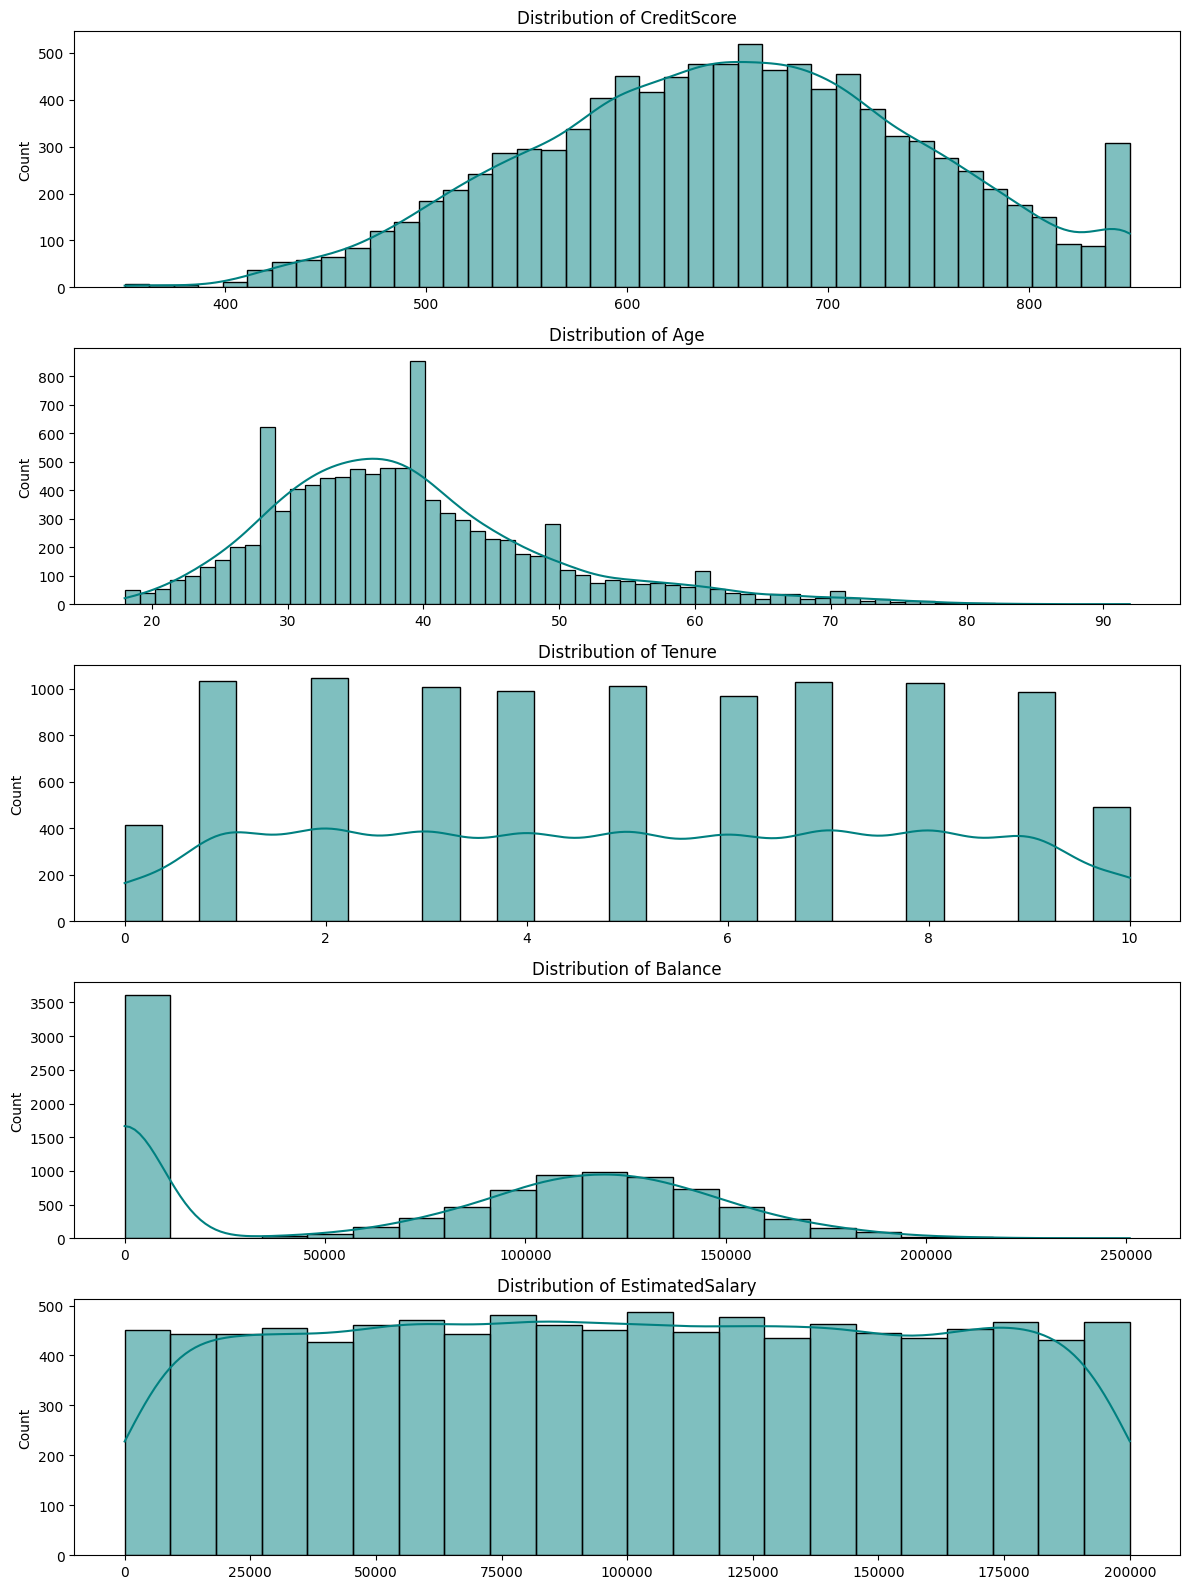

In [9]:
fig, axes = plt.subplots(len(to_check), 1, figsize=(12,16))
axes = axes.flatten()

for i, col in enumerate(to_check):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

It is easy to see that credit score, age and balance are skewed to some degree. These features would be checked during outlier detection. Tenure and Estimated Salary tends to be flat especially in the middle, thus for simplicity we might assume they are some sort of uniform and not included in our outlier detection.

Here, we set outliers via IQR

In [10]:
con_df = df[['CreditScore', 'Age', 'Balance']].copy()

Q1 = con_df.quantile(0.25)
Q3 = con_df.quantile(0.75)

IQR = Q3 - Q1
lower_bnd = Q1 - 1.5*IQR
upper_bnd = Q3 + 1.5*IQR

out_mask = ((con_df < lower_bnd) | (con_df > upper_bnd)).any(axis=1)
out_df = df[out_mask]
display(out_df.head())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,EstimatedSalary,Exited
1047,1194,15779947,Thomas,363,Spain,Female,28,6,146098.43,100615.14,1
1293,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,119346.88,1
1735,2580,15597896,Ozoemena,365,Germany,Male,30,0,127760.07,81537.85,1
4570,9211,15792650,Watts,382,Spain,Male,36,0,0.00,179540.73,1
5638,1839,15758813,Campbell,350,Germany,Male,39,0,109733.20,123602.11,1


### Check Imbalanced Data

In [11]:
print(df['Exited'].value_counts())

## ideal ratio via rule of thumb: between n/2 +- sqrt(2) for 95% confidence balanced

n_data = len(df)
ideal_low = (n_data/2) - np.sqrt(n_data)
ideal_high = (n_data/2) + np.sqrt(n_data)

print(f"Ideal range: {ideal_low}-{ideal_high}")

Exited
0    7963
1    2037
Name: count, dtype: int64
Ideal range: 4900.0-5100.0


The number of non-churn is way above ideal range (and number of churn is way below), so we assume that the data is imbalanced.

## Saving Data

In [12]:
if not os.path.exists('data/eda'):
    os.makedirs('data/eda')

## save raw data
with open('data/eda/raw_data.pkl', 'wb') as file:
    dump(raw_df, file)

## save data
with open('data/eda/data.pkl', 'wb') as file:
    dump(df, file)

## save outlier data
with open('data/eda/out_data.pkl', 'wb') as file:
    dump(out_df, file)


### Test Loading

In [13]:
with open('data/eda/raw_data.pkl', 'rb') as file:
    test_raw = load(file)

display(test_raw.head())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,EstimatedSalary,Exited
0,747,15787619,Hsieh,844,France,Male,18,2,160980.03,145936.28,0
1,1620,15770309,McDonald,656,France,Male,18,10,151762.74,127014.32,0
2,1679,15569178,Kharlamov,570,France,Female,18,4,82767.42,71811.90,0
3,2022,15795519,Vasiliev,716,Germany,Female,18,3,128743.80,197322.13,0
4,2137,15621893,Bellucci,727,France,Male,18,4,133550.67,46941.41,0
